# 04 - Trayectoria, indicadores y estados

## 1. Dependencias

In [1]:
#Instalar dependencias
%pip install pandas numpy scikit-learn matplotlib joblib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Configuración

In [2]:
#Librerías
import platform
import sys
from pathlib import Path
import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from matplotlib.ticker import FuncFormatter
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [3]:
#Configuración
SEMILLA = 20260727
UMBRAL_CONFIANZA = 0.50
UMBRAL_CONFIANZA_ALTA = 0.75
MIN_DIAS_TRAYECTORIA = 30
MIN_TRANSACCIONES_TRAYECTORIA = 10
MIN_PCT_CLASIFICABLE = 70.0
PERFIL_GRAFICA = 'PERF_0042'
VERSION_MODELO = 'fincoach_estados_trayectoria_mvp_v3'

MAPEO_ESTADOS = {
    'acumulacion_estable': 'saludable',
    'equilibrio_sostenible': 'saludable',
    'variable_resiliente': 'saludable',
    'uso_planificado_reserva': 'en_observacion',
    'deterioro_reciente': 'en_observacion',
    'fragilidad_sostenida': 'en_riesgo',
    'situacion_critica': 'en_riesgo',
}

ruta_perfiles = Path('../Datasets/perfil_integral_usuario.csv')
ruta_transacciones = Path('../Datasets/transacciones_contextualizadas.csv')
ruta_trayectorias = Path('../Datasets/trayectorias_financieras.csv')
ruta_recurrencias = Path('../Resultados/03_recurrencias_observadas.csv')
ruta_tendencias = Path('../Resultados/03_tendencias_observadas.csv')
ruta_eventos = Path('../Resultados/03_eventos_inusuales.csv')
ruta_modelo = Path('../Modelos/04_estados_trayectoria.joblib')
ruta_resultados = Path('../Resultados')
ruta_graficas = ruta_resultados / 'Graficas'

versiones = pd.DataFrame([
    {'componente': 'python', 'version': sys.version.split()[0]},
    {'componente': 'pandas', 'version': pd.__version__},
    {'componente': 'numpy', 'version': np.__version__},
    {'componente': 'scikit-learn', 'version': sklearn.__version__},
    {'componente': 'matplotlib', 'version': matplotlib.__version__},
    {'componente': 'sistema', 'version': platform.platform()},
])

display(versiones)

,componente,version
0,python,3.14.3
1,pandas,3.0.3
2,numpy,2.5.1
3,scikit-learn,1.9.0
4,matplotlib,3.11.1
5,sistema,macOS-26.5.2-arm64-arm-64bit-Mach-O


## 3. Carga de datos

In [4]:
#Cargar datos
rutas_requeridas = [
    ruta_perfiles,
    ruta_transacciones,
    ruta_trayectorias,
    ruta_recurrencias,
    ruta_tendencias,
    ruta_eventos,
]

for ruta in rutas_requeridas:
    assert ruta.exists(), f'No existe {ruta}'

perfiles = pd.read_csv(ruta_perfiles, low_memory=False)
transacciones = pd.read_csv(ruta_transacciones, low_memory=False)
trayectorias = pd.read_csv(ruta_trayectorias, low_memory=False)
recurrencias = pd.read_csv(ruta_recurrencias, low_memory=False)
tendencias_temporales = pd.read_csv(ruta_tendencias, low_memory=False)
eventos_inusuales = pd.read_csv(ruta_eventos, low_memory=False)

for columna in ['fecha_corte', 'periodo_desde', 'periodo_hasta']:
    trayectorias[columna] = pd.to_datetime(trayectorias[columna], errors='coerce')

transacciones['fecha'] = pd.to_datetime(transacciones['fecha'], errors='coerce')
contexto_perfiles = perfiles[[
    'perfil_id',
    'estado_ingreso_actual',
    'objetivo_proximo',
]].copy()
contexto_perfiles['objetivo_declarado'] = ~contexto_perfiles['objetivo_proximo'].astype('string').fillna('no_declarada').str.lower().isin([
    'no_declarada',
    'no_declarado',
    'no declarada',
    'no declarado',
    'ninguna',
])
trayectorias = trayectorias.merge(
    contexto_perfiles[['perfil_id', 'estado_ingreso_actual', 'objetivo_declarado']],
    on='perfil_id',
    how='left',
    validate='many_to_one',
)

resumen_fuentes = pd.DataFrame([
    {'fuente': 'perfiles', 'filas': len(perfiles), 'perfiles': perfiles['perfil_id'].nunique()},
    {'fuente': 'transacciones', 'filas': len(transacciones), 'perfiles': transacciones['perfil_id'].nunique()},
    {'fuente': 'trayectorias', 'filas': len(trayectorias), 'perfiles': trayectorias['perfil_id'].nunique()},
    {'fuente': 'recurrencias', 'filas': len(recurrencias), 'perfiles': recurrencias['perfil_id'].nunique()},
    {'fuente': 'tendencias', 'filas': len(tendencias_temporales), 'perfiles': tendencias_temporales['perfil_id'].nunique()},
    {'fuente': 'eventos inusuales', 'filas': len(eventos_inusuales), 'perfiles': eventos_inusuales['perfil_id'].nunique()},
])

display(resumen_fuentes)
display(trayectorias.head(5))

,fuente,filas,perfiles
0,perfiles,200,200
1,transacciones,17284,200
2,trayectorias,600,200
3,recurrencias,8902,200
4,tendencias,396,200
5,eventos inusuales,646,187


,ventana_id,perfil_id,estado_alcance_mvp,fecha_corte,periodo_desde,periodo_hasta,tipo_ventana,dias_observados,transacciones_observadas,porcentaje_transacciones_clasificables,...,ingresos_variables,ingresos_estacionales,periodos_sin_ingreso,gastos_fijos,gastos_variables,pagos_capital,pagos_intereses,nueva_deuda,estado_ingreso_actual,objetivo_declarado
0,VEN_0001_1,PERF_0001,dentro_del_mvp,2026-04-30,2026-04-01,2026-04-30,acumulada_30_dias,30,31,93.5484,...,0,0,0,1736000,1798000,135000,0,0,mixto,True
1,VEN_0001_2,PERF_0001,dentro_del_mvp,2026-05-31,2026-04-01,2026-05-31,acumulada_61_dias,61,63,95.2381,...,0,0,0,4070000,2998000,389000,0,0,mixto,True
2,VEN_0001_3,PERF_0001,dentro_del_mvp,2026-06-30,2026-04-01,2026-06-30,acumulada_91_dias,91,96,94.7917,...,0,0,0,6466000,4136000,519000,143000,0,mixto,True
3,VEN_0002_1,PERF_0002,dentro_del_mvp,2026-04-30,2026-04-01,2026-04-30,acumulada_30_dias,30,30,96.6667,...,0,0,0,1350000,2233000,0,0,0,fijo,True
4,VEN_0002_2,PERF_0002,dentro_del_mvp,2026-05-31,2026-04-01,2026-05-31,acumulada_61_dias,61,61,98.3607,...,0,0,0,2822000,4344000,0,0,0,fijo,True


## 4. Contrato, cobertura y separación de perfiles

In [5]:
#Validar contrato
indicadores_crudos = [
    'actividad_A',
    'balance_operativo_B',
    'presion_deficit_Q',
    'caida_maxima_M',
    'tiempo_sin_recuperar_U_dias',
    'recuperacion_R',
    'curvatura_K',
    'variabilidad_ingresos_V',
    'cobertura_esencial_L_meses',
    'dependencia_externa_X',
    'crecimiento_deuda_J',
]

columnas_requeridas = [
    'ventana_id',
    'perfil_id',
    'fecha_corte',
    'periodo_desde',
    'periodo_hasta',
    'dias_observados',
    'transacciones_observadas',
    'porcentaje_transacciones_clasificables',
    'deuda_inicial',
    'deuda_final',
    'ingresos_fijos',
    'ingresos_variables',
    'ingresos_estacionales',
    'periodos_sin_ingreso',
    'gastos_fijos',
    'gastos_variables',
    'pagos_capital',
    'pagos_intereses',
    'nueva_deuda',
    'estado_ingreso_actual',
    'objetivo_declarado',
    'estado_trayectoria',
    'particion',
    'version_metodologia',
    'version_esquema',
    *indicadores_crudos,
]

columnas_recurrencias_requeridas = [
    'perfil_id',
    'regularidad_financiera_dataset',
    'cadencia_observada',
    'estado_recurrencia',
    'recurrencia_temporal_observada',
]

columnas_faltantes = sorted(set(columnas_requeridas) - set(trayectorias.columns))
columnas_recurrencias_faltantes = sorted(set(columnas_recurrencias_requeridas) - set(recurrencias.columns))
perfiles_por_particion = trayectorias.groupby('perfil_id')['particion'].nunique()
estados_descriptivos = list(MAPEO_ESTADOS)
errores_contrato = pd.DataFrame([
    {'control': 'columnas requeridas', 'errores': len(columnas_faltantes)},
    {'control': 'columnas de recurrencias requeridas', 'errores': len(columnas_recurrencias_faltantes)},
    {'control': 'fechas válidas', 'errores': int(trayectorias[['fecha_corte', 'periodo_desde', 'periodo_hasta']].isna().any(axis=1).sum())},
    {'control': 'indicadores disponibles', 'errores': int(trayectorias[indicadores_crudos].isna().any(axis=1).sum())},
    {'control': 'partición válida', 'errores': int((~trayectorias['particion'].isin(['train', 'validation', 'test'])).sum())},
    {'control': 'perfil en una sola partición', 'errores': int(perfiles_por_particion.gt(1).sum())},
    {'control': 'ventana temporal válida', 'errores': int(trayectorias['periodo_hasta'].lt(trayectorias['periodo_desde']).sum())},
    {'control': 'porcentaje entre 0 y 100', 'errores': int((~trayectorias['porcentaje_transacciones_clasificables'].between(0, 100)).sum())},
    {'control': 'siete estados válidos', 'errores': int((~trayectorias['estado_trayectoria'].isin(estados_descriptivos)).sum())},
    {'control': 'contexto de ingreso disponible', 'errores': int(trayectorias['estado_ingreso_actual'].isna().sum())},
    {'control': 'objetivo estructurado disponible', 'errores': int(trayectorias['objetivo_declarado'].isna().sum())},
    {'control': 'esquema de trayectorias actualizado', 'errores': int(trayectorias['version_esquema'].ne('fincoach_mvp_estructurado_v3.0').sum())},
    {'control': 'metodología de trayectorias actualizada', 'errores': int(trayectorias['version_metodologia'].ne('roadmap_14_mvp_estructurado_v3.0').sum())},
])

display(errores_contrato)
assert not columnas_faltantes, f'Faltan columnas: {columnas_faltantes}'
assert not columnas_recurrencias_faltantes, f'Faltan columnas en recurrencias: {columnas_recurrencias_faltantes}'
assert errores_contrato['errores'].eq(0).all(), 'El contrato de trayectorias contiene errores'

,control,errores
0,columnas requeridas,0
1,columnas de recurrencias requeridas,0
2,fechas válidas,0
3,indicadores disponibles,0
4,partición válida,0
5,perfil en una sola partición,0
6,ventana temporal válida,0
7,porcentaje entre 0 y 100,0
8,siete estados válidos,0
9,contexto de ingreso disponible,0


In [6]:
#Mostrar cobertura
cobertura_estados = pd.crosstab(
    trayectorias['estado_trayectoria'],
    trayectorias['particion'],
).reindex(columns=['train', 'validation', 'test'], fill_value=0)
cobertura_ventanas = pd.crosstab(
    trayectorias['tipo_ventana'],
    trayectorias['particion'],
).reindex(columns=['train', 'validation', 'test'], fill_value=0)

display(cobertura_estados)
display(cobertura_ventanas)
assert cobertura_estados.gt(0).all().all(), 'Algún estado no aparece en todas las particiones'

particion,train,validation,test
estado_trayectoria,,,
acumulacion_estable,39,3,12
deterioro_reciente,23,4,5
equilibrio_sostenible,30,13,8
fragilidad_sostenida,53,8,12
situacion_critica,192,45,44
uso_planificado_reserva,54,12,7
variable_resiliente,29,5,2


particion,train,validation,test
tipo_ventana,,,
acumulada_30_dias,140,30,30
acumulada_61_dias,140,30,30
acumulada_91_dias,140,30,30


## 5. Auditoría de fórmulas e invariantes

In [7]:
#Auditar fórmulas
mascara_train = trayectorias['particion'].eq('train')
actividad_roadmap = (
    trayectorias['ingresos_generados']
    + trayectorias['apoyos_recibidos']
    + trayectorias['gastos_totales']
)

balance_roadmap = (
    trayectorias['ingresos_generados']
    + trayectorias['apoyos_recibidos']
    - trayectorias['gastos_totales']
)

liquidez_calculada = (
    trayectorias['liquidez_inicial']
    + trayectorias['ingresos_generados']
    + trayectorias['apoyos_recibidos']
    + trayectorias['prestamos_recibidos']
    + trayectorias['devoluciones_y_reembolsos']
    + trayectorias['otros_recursos_recibidos']
    - trayectorias['gastos_totales']
)

deuda_calculada = (
    trayectorias['deuda_inicial']
    + trayectorias['nueva_deuda']
    - trayectorias['pagos_capital']
)
pagos_deuda_calculados = trayectorias['pagos_capital'] + trayectorias['pagos_intereses']
entradas_totales = (
    trayectorias['ingresos_generados']
    + trayectorias['apoyos_recibidos']
    + trayectorias['prestamos_recibidos']
    + trayectorias['devoluciones_y_reembolsos']
    + trayectorias['otros_recursos_recibidos']
)
ingresos_por_regularidad = trayectorias['ingresos_fijos'] + trayectorias['ingresos_variables'] + trayectorias['ingresos_estacionales']
gastos_por_regularidad = trayectorias['gastos_fijos'] + trayectorias['gastos_variables']

trayectorias['actividad_modelo_A'] = actividad_roadmap
trayectorias['balance_modelo_B'] = balance_roadmap

auditoria_convenciones = pd.DataFrame([
    {'formula': 'actividad_A', 'convencion': 'roadmap sin financiación', 'ventanas_diferentes_al_archivo': int((~np.isclose(trayectorias['actividad_A'], actividad_roadmap, atol=1)).sum())},
    {'formula': 'balance_operativo_B', 'convencion': 'ingresos y apoyos menos salidas', 'ventanas_diferentes_al_archivo': int((~np.isclose(trayectorias['balance_operativo_B'], balance_roadmap, atol=1)).sum())},
])

auditoria_invariantes = pd.DataFrame([
    {'formula': 'liquidez_final', 'unidad': 'COP al cierre', 'errores': int((~np.isclose(trayectorias['liquidez_final'], liquidez_calculada, atol=1)).sum())},
    {'formula': 'deuda_final', 'unidad': 'COP al cierre', 'errores': int((~np.isclose(trayectorias['deuda_final'], deuda_calculada, atol=1)).sum())},
    {'formula': 'pagos_deuda', 'unidad': 'COP del periodo', 'errores': int((~np.isclose(trayectorias['pagos_deuda'], pagos_deuda_calculados, atol=1)).sum())},
    {'formula': 'nueva_deuda', 'unidad': 'COP del periodo', 'errores': int((~np.isclose(trayectorias['prestamos_recibidos'], trayectorias['nueva_deuda'], atol=1)).sum())},
    {'formula': 'ingresos por regularidad', 'unidad': 'COP del periodo', 'errores': int((~np.isclose(entradas_totales, ingresos_por_regularidad, atol=1)).sum())},
    {'formula': 'gastos fijos y variables', 'unidad': 'COP del periodo', 'errores': int((~np.isclose(trayectorias['gastos_totales'], gastos_por_regularidad, atol=1)).sum())},
    {'formula': 'gastos no negativos', 'unidad': 'conteo de ventanas', 'errores': int((trayectorias[['gastos_fijos', 'gastos_variables']] < 0).any(axis=1).sum())},
])

resumen_regularidad = trayectorias.groupby('particion')[
    ['ingresos_fijos', 'ingresos_variables', 'ingresos_estacionales', 'gastos_fijos', 'gastos_variables']
].sum().reset_index()

display(auditoria_convenciones)
display(auditoria_invariantes)
display(resumen_regularidad)
assert auditoria_convenciones['ventanas_diferentes_al_archivo'].eq(0).all(), 'Las fórmulas del vector no coinciden con el archivo'
assert auditoria_invariantes['errores'].eq(0).all(), 'Los saldos finales no reconciliaron'

,formula,convencion,ventanas_diferentes_al_archivo
0,actividad_A,roadmap sin financiación,0
1,balance_operativo_B,ingresos y apoyos menos salidas,0


,formula,unidad,errores
0,liquidez_final,COP al cierre,0
1,deuda_final,COP al cierre,0
2,pagos_deuda,COP del periodo,0
3,nueva_deuda,COP del periodo,0
4,ingresos por regularidad,COP del periodo,0
5,gastos fijos y variables,COP del periodo,0
6,gastos no negativos,conteo de ventanas,0


,particion,ingresos_fijos,ingresos_variables,ingresos_estacionales,gastos_fijos,gastos_variables
0,test,504701000,41480000,60276000,561749000,615102000
1,train,2105874000,238625000,328419000,2807993000,2852464000
2,validation,447734000,60388000,49352000,637727000,623655000


In [8]:
#Documentar indicadores
ficha_indicadores = pd.DataFrame([
    {'indicador': 'B', 'nombre': 'balance operativo relativo', 'unidad_modelo': 'proporción de actividad', 'precaucion': 'un valor negativo puede representar uso planificado de reserva'},
    {'indicador': 'Q', 'nombre': 'presión de déficit', 'unidad_modelo': 'proporción de actividad', 'precaucion': 'se interpreta junto con liquidez y recuperación'},
    {'indicador': 'M', 'nombre': 'caída máxima', 'unidad_modelo': 'proporción de actividad', 'precaucion': 'compara a la persona con su propio máximo'},
    {'indicador': 'U', 'nombre': 'tiempo sin recuperar', 'unidad_modelo': 'proporción de la ventana', 'precaucion': 'cero calculado no equivale a dato faltante'},
    {'indicador': 'R', 'nombre': 'recuperación', 'unidad_modelo': 'proporción recuperada', 'precaucion': 'es relevante para ingresos variables'},
    {'indicador': 'K', 'nombre': 'curvatura', 'unidad_modelo': 'curvatura por actividad', 'precaucion': 'depende del suavizado de la trayectoria'},
    {'indicador': 'V', 'nombre': 'variabilidad de ingresos', 'unidad_modelo': 'proporción normalizada', 'precaucion': 'variabilidad alta no equivale a riesgo'},
    {'indicador': 'L', 'nombre': 'cobertura esencial', 'unidad_modelo': 'meses', 'precaucion': 'la esencialidad debe estar confirmada'},
    {'indicador': 'X', 'nombre': 'dependencia externa', 'unidad_modelo': 'proporción de entradas', 'precaucion': 'distingue apoyo de financiación'},
    {'indicador': 'J', 'nombre': 'crecimiento de deuda', 'unidad_modelo': 'cambio de deuda sobre actividad', 'precaucion': 'la finalidad de la deuda requiere contexto'},
])

display(ficha_indicadores)

,indicador,nombre,unidad_modelo,precaucion
0,B,balance operativo relativo,proporción de actividad,un valor negativo puede representar uso planif...
1,Q,presión de déficit,proporción de actividad,se interpreta junto con liquidez y recuperación
2,M,caída máxima,proporción de actividad,compara a la persona con su propio máximo
3,U,tiempo sin recuperar,proporción de la ventana,cero calculado no equivale a dato faltante
4,R,recuperación,proporción recuperada,es relevante para ingresos variables
5,K,curvatura,curvatura por actividad,depende del suavizado de la trayectoria
6,V,variabilidad de ingresos,proporción normalizada,variabilidad alta no equivale a riesgo
7,L,cobertura esencial,meses,la esencialidad debe estar confirmada
8,X,dependencia externa,proporción de entradas,distingue apoyo de financiación
9,J,crecimiento de deuda,cambio de deuda sobre actividad,la finalidad de la deuda requiere contexto


## 6. Vector normalizado de trayectoria

In [9]:
#Preparar indicadores
variables_numericas = [
    'balance_relativo_B',
    'presion_relativa_Q',
    'caida_relativa_M',
    'tiempo_sin_recuperar_U',
    'recuperacion_R',
    'curvatura_relativa_K',
    'variabilidad_ingresos_V',
    'cobertura_esencial_L_meses',
    'dependencia_externa_X',
    'crecimiento_deuda_relativo_J',
]
variables_contexto = [
    'estado_ingreso_actual',
    'objetivo_declarado',
]
variables_contexto_modelo = ['estado_ingreso_actual']
variables_modelo = variables_numericas + variables_contexto_modelo


def preparar_indicadores(datos):
    base = pd.DataFrame(datos).copy()
    columna_actividad = 'actividad_modelo_A' if 'actividad_modelo_A' in base.columns else 'actividad_A'
    columna_balance = 'balance_modelo_B' if 'balance_modelo_B' in base.columns else 'balance_operativo_B'
    actividad = pd.to_numeric(base[columna_actividad], errors='coerce').where(lambda serie: serie.gt(0))
    dias = pd.to_numeric(base['dias_observados'], errors='coerce').where(lambda serie: serie.gt(0))
    salida = pd.DataFrame(index=base.index)
    salida['balance_relativo_B'] = pd.to_numeric(base[columna_balance], errors='coerce') / actividad
    salida['presion_relativa_Q'] = pd.to_numeric(base['presion_deficit_Q'], errors='coerce') / actividad
    salida['caida_relativa_M'] = pd.to_numeric(base['caida_maxima_M'], errors='coerce') / actividad
    salida['tiempo_sin_recuperar_U'] = pd.to_numeric(base['tiempo_sin_recuperar_U_dias'], errors='coerce') / dias
    salida['recuperacion_R'] = pd.to_numeric(base['recuperacion_R'], errors='coerce')
    salida['curvatura_relativa_K'] = pd.to_numeric(base['curvatura_K'], errors='coerce') / actividad
    salida['variabilidad_ingresos_V'] = pd.to_numeric(base['variabilidad_ingresos_V'], errors='coerce')
    salida['cobertura_esencial_L_meses'] = pd.to_numeric(base['cobertura_esencial_L_meses'], errors='coerce')
    salida['dependencia_externa_X'] = pd.to_numeric(base['dependencia_externa_X'], errors='coerce')
    deuda_inicial = pd.to_numeric(base['deuda_inicial'], errors='coerce')
    deuda_final = pd.to_numeric(base['deuda_final'], errors='coerce')
    salida['crecimiento_deuda_relativo_J'] = (deuda_final - deuda_inicial) / actividad
    salida['estado_ingreso_actual'] = base['estado_ingreso_actual'].astype('string')
    salida['objetivo_declarado'] = base['objetivo_declarado'].astype('boolean')
    return salida[variables_modelo]


X = preparar_indicadores(trayectorias)
y = trayectorias['estado_trayectoria']
display(X[variables_numericas].describe().T.round(4))
display(X[variables_contexto_modelo].value_counts(dropna=False).rename('ventanas').reset_index())

assert not X.isna().any().any(), 'El vector normalizado contiene valores faltantes'

,count,mean,std,min,25%,50%,75%,max
balance_relativo_B,600.0,-0.4342,0.4012,-1.0000,-0.7895,-0.5309,-0.0703,0.3038
presion_relativa_Q,600.0,0.4649,0.3564,0.0000,0.0703,0.5309,0.7895,1.0000
caida_relativa_M,600.0,0.5106,0.2854,0.0357,0.2343,0.5179,0.7710,1.0000
tiempo_sin_recuperar_U,600.0,0.7586,0.3345,0.0000,0.6598,0.9451,0.9780,0.9890
recuperacion_R,600.0,0.3523,0.3928,0.0000,0.0000,0.1642,0.7542,1.0000
curvatura_relativa_K,600.0,-0.0006,0.0019,-0.0103,-0.0010,0.0000,0.0000,0.0045
variabilidad_ingresos_V,600.0,0.1080,0.2320,0.0000,0.0000,0.0000,0.1086,1.0000
cobertura_esencial_L_meses,600.0,1.6162,2.3251,0.0000,0.0000,0.3550,2.5373,11.8961
dependencia_externa_X,600.0,0.2101,0.3339,0.0000,0.0000,0.0279,0.2453,1.0000
crecimiento_deuda_relativo_J,600.0,0.0036,0.0371,-0.1524,-0.0132,0.0000,0.0000,0.2749


,estado_ingreso_actual,ventanas
0,fijo,150
1,variable,150
2,mixto,120
3,apoyo,60
4,sin_ingresos,60
5,estacional,60


In [10]:
#Separar particiones
mascara_validation = trayectorias['particion'].eq('validation')
mascara_test = trayectorias['particion'].eq('test')

X_train = X.loc[mascara_train]
y_train = y.loc[mascara_train]
X_validation = X.loc[mascara_validation]
y_validation = y.loc[mascara_validation]
X_test = X.loc[mascara_test]
y_test = y.loc[mascara_test]

particiones_modelo = pd.DataFrame([
    {'particion': 'train', 'filas': len(X_train), 'perfiles': trayectorias.loc[mascara_train, 'perfil_id'].nunique()},
    {'particion': 'validation', 'filas': len(X_validation), 'perfiles': trayectorias.loc[mascara_validation, 'perfil_id'].nunique()},
    {'particion': 'test', 'filas': len(X_test), 'perfiles': trayectorias.loc[mascara_test, 'perfil_id'].nunique()},
])

display(particiones_modelo)

,particion,filas,perfiles
0,train,420,140
1,validation,90,30
2,test,90,30


## 7. Entrenamiento y selección

In [11]:
#Definir modelos
preprocesador = ColumnTransformer([
    ('indicadores', Pipeline([
        ('faltantes', SimpleImputer(strategy='median')),
        ('escala', StandardScaler()),
    ]), variables_numericas),
    ('contexto', Pipeline([
        ('faltantes', SimpleImputer(strategy='most_frequent')),
        ('categorias', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), variables_contexto_modelo),
])

modelos_candidatos = {
    'regresion_logistica': Pipeline([
        ('preparacion', clone(preprocesador)),
        ('modelo', LogisticRegression(
            C=1.0,
            max_iter=5000,
            class_weight='balanced',
            random_state=SEMILLA,
        )),
    ]),
    'bosque_aleatorio': Pipeline([
        ('preparacion', clone(preprocesador)),
        ('modelo', RandomForestClassifier(
            n_estimators=500,
            max_depth=12,
            min_samples_leaf=2,
            max_features='sqrt',
            class_weight='balanced_subsample',
            random_state=SEMILLA,
            n_jobs=-1,
        )),
    ]),
}

In [12]:
#Comparar modelos
modelos_entrenados = {}
metricas_validation = []

for nombre, modelo in modelos_candidatos.items():
    modelo.fit(X_train, y_train)
    prediccion = modelo.predict(X_validation)
    probabilidades = modelo.predict_proba(X_validation)
    modelos_entrenados[nombre] = modelo
    metricas_validation.append({
        'modelo': nombre,
        'accuracy': round(accuracy_score(y_validation, prediccion), 4),
        'balanced_accuracy': round(balanced_accuracy_score(y_validation, prediccion), 4),
        'f1_macro': round(f1_score(y_validation, prediccion, average='macro'), 4),
        'log_loss': round(log_loss(y_validation, probabilidades, labels=modelo.classes_), 4),
    })

metricas_validation = pd.DataFrame(metricas_validation).sort_values(
    ['f1_macro', 'balanced_accuracy'],
    ascending=False,
).reset_index(drop=True)
nombre_modelo_final = metricas_validation.loc[0, 'modelo']

display(metricas_validation)
print(f'Modelo seleccionado: {nombre_modelo_final}')

,modelo,accuracy,balanced_accuracy,f1_macro,log_loss
0,bosque_aleatorio,0.9889,0.9821,0.9746,0.1423
1,regresion_logistica,0.9000,0.8708,0.8336,0.3437


Modelo seleccionado: bosque_aleatorio


In [13]:
#Entrenar modelo final
mascara_desarrollo = mascara_train | mascara_validation
X_desarrollo = X.loc[mascara_desarrollo]
y_desarrollo = y.loc[mascara_desarrollo]
modelo_final = clone(modelos_candidatos[nombre_modelo_final])
modelo_final.fit(X_desarrollo, y_desarrollo)

prediccion_test = modelo_final.predict(X_test)
probabilidades_test = modelo_final.predict_proba(X_test)
reporte_test = classification_report(
    y_test,
    prediccion_test,
    output_dict=True,
    zero_division=0,
)
metricas_test = pd.DataFrame([{
    'modelo': nombre_modelo_final,
    'accuracy': round(accuracy_score(y_test, prediccion_test), 4),
    'balanced_accuracy': round(balanced_accuracy_score(y_test, prediccion_test), 4),
    'f1_macro': round(f1_score(y_test, prediccion_test, average='macro'), 4),
    'log_loss': round(log_loss(y_test, probabilidades_test, labels=modelo_final.classes_), 4),
}])
reporte_clases = pd.DataFrame(reporte_test).T.round(4)

display(metricas_test)
display(reporte_clases)

,modelo,accuracy,balanced_accuracy,f1_macro,log_loss
0,bosque_aleatorio,0.9556,0.9524,0.9469,0.1595


,precision,recall,f1-score,support
acumulacion_estable,1.0000,1.0000,1.0000,12.0000
deterioro_reciente,0.8333,1.0000,0.9091,5.0000
equilibrio_sostenible,0.8889,1.0000,0.9412,8.0000
fragilidad_sostenida,1.0000,0.6667,0.8000,12.0000
situacion_critica,0.9565,1.0000,0.9778,44.0000
uso_planificado_reserva,1.0000,1.0000,1.0000,7.0000
variable_resiliente,1.0000,1.0000,1.0000,2.0000
accuracy,0.9556,0.9556,0.9556,0.9556
macro avg,0.9541,0.9524,0.9469,90.0000
weighted avg,0.9596,0.9556,0.9522,90.0000


## 8. Evaluación visual e importancia

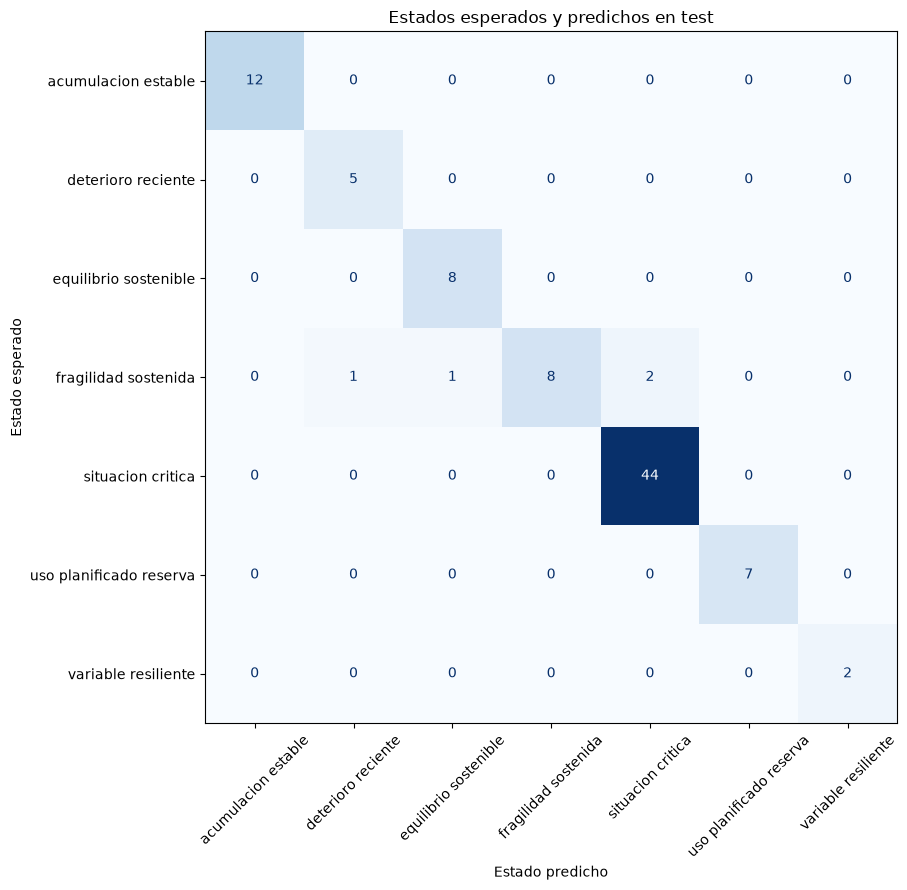

In [14]:
#Mostrar matriz de confusión
etiquetas_estados = sorted(y.unique())
figura, eje = plt.subplots(figsize=(11, 9))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    prediccion_test,
    labels=etiquetas_estados,
    display_labels=[estado.replace('_', ' ') for estado in etiquetas_estados],
    cmap='Blues',
    colorbar=False,
    xticks_rotation=45,
    ax=eje,
)

eje.set_title('Estados esperados y predichos en test')
eje.set_xlabel('Estado predicho')
eje.set_ylabel('Estado esperado')
figura.tight_layout()

ruta_graficas.mkdir(parents=True, exist_ok=True)
figura.savefig(ruta_graficas / '04_matriz_confusion_estados.png', dpi=180, bbox_inches='tight')
plt.show()

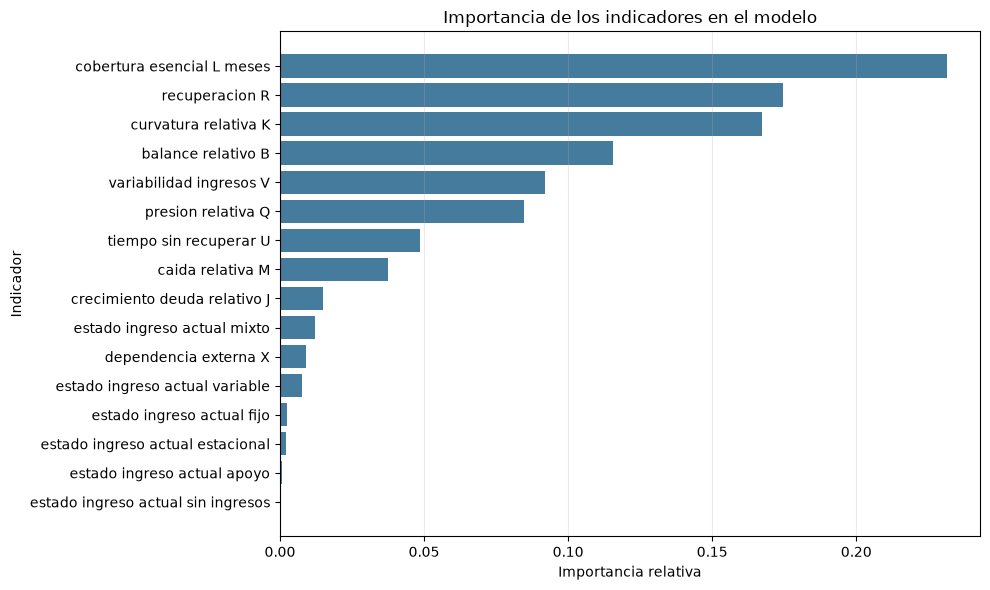

,indicador,importancia
7,cobertura_esencial_L_meses,0.231365
4,recuperacion_R,0.174451
5,curvatura_relativa_K,0.167158
0,balance_relativo_B,0.115553
6,variabilidad_ingresos_V,0.091836
1,presion_relativa_Q,0.084733
3,tiempo_sin_recuperar_U,0.048500
2,caida_relativa_M,0.037343
9,crecimiento_deuda_relativo_J,0.014962
13,estado_ingreso_actual_mixto,0.012320


In [15]:
#Mostrar importancia
estimador_final = modelo_final.named_steps['modelo']
nombres_transformados = [
    nombre.split('__', 1)[-1]
    for nombre in modelo_final.named_steps['preparacion'].get_feature_names_out()
]

if hasattr(estimador_final, 'feature_importances_'):
    importancia_valores = estimador_final.feature_importances_
else:
    importancia_valores = np.abs(estimador_final.coef_).mean(axis=0)

importancia_indicadores = pd.DataFrame({
    'indicador': nombres_transformados,
    'importancia': importancia_valores,
}).sort_values('importancia', ascending=True)

figura, eje = plt.subplots(figsize=(10, 6))
eje.barh(
    [indicador.replace('_', ' ') for indicador in importancia_indicadores['indicador']],
    importancia_indicadores['importancia'],
    color='#457B9D',
)

eje.set_title('Importancia de los indicadores en el modelo')
eje.set_xlabel('Importancia relativa')
eje.set_ylabel('Indicador')
eje.grid(axis='x', alpha=0.25)
figura.tight_layout()
figura.savefig(ruta_graficas / '04_importancia_indicadores.png', dpi=180, bbox_inches='tight')
plt.show()

display(importancia_indicadores.sort_values('importancia', ascending=False))

## 9. Inferencia con evidencia y porcentajes

In [16]:
#Definir inferencia
campos_evidencia = [
    'dias_observados',
    'transacciones_observadas',
    'porcentaje_transacciones_clasificables',
    'deuda_inicial',
    'deuda_final',
    *indicadores_crudos,
    *variables_contexto,
]
contextos_ingreso_permitidos = sorted(X['estado_ingreso_actual'].astype(str).unique())


def revisar_evidencia(entrada):
    faltantes = [
        campo
        for campo in campos_evidencia
        if campo not in entrada or pd.isna(entrada[campo])
    ]
    motivos = []

    if faltantes:
        motivos.append('indicadores_faltantes:' + '|'.join(faltantes))
    if not faltantes:
        if float(entrada['dias_observados']) < MIN_DIAS_TRAYECTORIA:
            motivos.append('historia_menor_a_30_dias')
        if float(entrada['transacciones_observadas']) < MIN_TRANSACCIONES_TRAYECTORIA:
            motivos.append('menos_de_10_transacciones')
        if float(entrada['porcentaje_transacciones_clasificables']) < MIN_PCT_CLASIFICABLE:
            motivos.append('cobertura_de_clasificacion_insuficiente')
        if float(entrada['porcentaje_transacciones_clasificables']) > 100:
            motivos.append('porcentaje_clasificable_fuera_de_rango')
        if float(entrada['actividad_A']) <= 0:
            motivos.append('actividad_financiera_no_calculable')
        if str(entrada['estado_ingreso_actual']) not in contextos_ingreso_permitidos:
            motivos.append('contexto_de_ingreso_fuera_del_mvp')
        if not isinstance(entrada['objetivo_declarado'], (bool, np.bool_)):
            motivos.append('objetivo_declarado_debe_ser_booleano')

    return motivos


def mapear_estado_reto(estado, indicadores):
    if estado == 'variable_resiliente':
        recuperacion = float(indicadores['recuperacion_R'])
        cobertura = float(indicadores['cobertura_esencial_L_meses'])
        return 'saludable' if recuperacion >= 0.5 and cobertura >= 1 else 'en_observacion'
    return MAPEO_ESTADOS.get(estado, 'no_disponible')


def clasificar_trayectoria(entrada):
    motivos = revisar_evidencia(entrada)

    if motivos:
        return {
            'estado_calculo': 'evidencia_insuficiente',
            'estado_trayectoria': 'no_disponible',
            'estado_reto': 'no_disponible',
            'estado_mas_probable': 'no_disponible',
            'confianza_pct': np.nan,
            'nivel_incertidumbre': 'alta',
            'motivos': motivos,
            'indicadores_normalizados': {},
            'contexto_utilizado': {},
            'porcentajes_estado': {},
        }

    vector = preparar_indicadores(pd.DataFrame([entrada]))
    probabilidades = modelo_final.predict_proba(vector)[0]
    posicion = int(np.argmax(probabilidades))
    confianza = float(probabilidades[posicion])
    estado_probable = modelo_final.classes_[posicion]
    porcentajes = {
        estado: round(float(probabilidad) * 100, 2)
        for estado, probabilidad in sorted(
            zip(modelo_final.classes_, probabilidades),
            key=lambda elemento: elemento[1],
            reverse=True,
        )
    }

    motivos_salida = []
    reserva_sin_meta = estado_probable == 'uso_planificado_reserva' and not bool(entrada['objetivo_declarado'])

    if confianza < UMBRAL_CONFIANZA:
        estado_salida = 'estado_incierto'
        estado_calculo = 'requiere_confirmacion'
        incertidumbre = 'alta'
        motivos_salida.append('confianza_inferior_al_umbral')
    elif reserva_sin_meta:
        estado_salida = 'estado_incierto'
        estado_calculo = 'requiere_confirmacion'
        incertidumbre = 'alta'
        motivos_salida.append('uso_de_reserva_sin_meta_confirmada')
    else:
        estado_salida = estado_probable
        estado_calculo = 'calculado'
        incertidumbre = 'baja' if confianza >= UMBRAL_CONFIANZA_ALTA else 'media'

    indicadores = vector[variables_numericas].iloc[0].astype(float).round(4).to_dict()
    estado_reto = mapear_estado_reto(estado_salida, indicadores)
    contexto_utilizado = {
        'estado_ingreso_actual': str(entrada['estado_ingreso_actual']),
        'objetivo_declarado': bool(entrada['objetivo_declarado']),
    }

    return {
        'estado_calculo': estado_calculo,
        'estado_trayectoria': estado_salida,
        'estado_reto': estado_reto,
        'estado_mas_probable': estado_probable,
        'confianza_pct': round(confianza * 100, 2),
        'nivel_incertidumbre': incertidumbre,
        'motivos': motivos_salida,
        'indicadores_normalizados': indicadores,
        'contexto_utilizado': contexto_utilizado,
        'porcentajes_estado': porcentajes,
    }

In [17]:
#Clasificar ventanas
resultados_modelo = []

for indice, fila in trayectorias.iterrows():
    resultado = clasificar_trayectoria(fila.to_dict())
    registro = {
        'ventana_id': fila['ventana_id'],
        'perfil_id': fila['perfil_id'],
        'fecha_corte': fila['fecha_corte'],
        'periodo_desde': fila['periodo_desde'],
        'periodo_hasta': fila['periodo_hasta'],
        'estado_esperado': fila['estado_trayectoria'],
        'estado_modelo': resultado['estado_trayectoria'],
        'estado_reto': resultado['estado_reto'],
        'estado_calculo_modelo': resultado['estado_calculo'],
        'confianza_pct': resultado['confianza_pct'],
        'nivel_incertidumbre_modelo': resultado['nivel_incertidumbre'],
        'estado_ingreso_actual': fila['estado_ingreso_actual'],
        'objetivo_declarado': fila['objetivo_declarado'],
        'calidad_datos': fila['calidad_datos'],
        'factores_positivos': fila['factores_positivos'],
        'factores_atencion': fila['factores_atencion'],
        'informacion_faltante': fila['informacion_faltante'],
        'explicacion_periodo': fila['explicacion_periodo'],
        'particion': fila['particion'],
    }

    for estado, porcentaje in resultado['porcentajes_estado'].items():
        registro[f'prob_{estado}_pct'] = porcentaje

    resultados_modelo.append(registro)

resultados_modelo = pd.DataFrame(resultados_modelo)
resumen_confianza = resultados_modelo.groupby(
    ['particion', 'estado_calculo_modelo']
).size().rename('ventanas').reset_index()

display(resumen_confianza)
display(resultados_modelo.head(5))

,particion,estado_calculo_modelo,ventanas
0,test,calculado,87
1,test,requiere_confirmacion,3
2,train,calculado,399
3,train,requiere_confirmacion,21
4,validation,calculado,85
5,validation,requiere_confirmacion,5


,ventana_id,perfil_id,fecha_corte,periodo_desde,periodo_hasta,estado_esperado,estado_modelo,estado_reto,estado_calculo_modelo,confianza_pct,...,informacion_faltante,explicacion_periodo,particion,prob_situacion_critica_pct,prob_fragilidad_sostenida_pct,prob_uso_planificado_reserva_pct,prob_acumulacion_estable_pct,prob_deterioro_reciente_pct,prob_equilibrio_sostenible_pct,prob_variable_resiliente_pct
0,VEN_0001_1,PERF_0001,2026-04-30,2026-04-01,2026-04-30,situacion_critica,situacion_critica,en_riesgo,calculado,98.82,...,ninguna_relevante_para_el_periodo,La ventana entre 2026-04-01 y 2026-04-30 muest...,train,98.82,0.61,0.58,0.00,0.00,0.00,0.00
1,VEN_0001_2,PERF_0001,2026-05-31,2026-04-01,2026-05-31,fragilidad_sostenida,fragilidad_sostenida,en_riesgo,calculado,85.73,...,ninguna_relevante_para_el_periodo,La ventana entre 2026-04-01 y 2026-05-31 muest...,train,0.84,85.73,9.19,0.00,3.78,0.47,0.00
2,VEN_0001_3,PERF_0001,2026-06-30,2026-04-01,2026-06-30,variable_resiliente,variable_resiliente,saludable,calculado,94.03,...,ninguna_relevante_para_el_periodo,La ventana entre 2026-04-01 y 2026-06-30 muest...,train,0.00,0.39,0.04,0.49,0.00,5.05,94.03
3,VEN_0002_1,PERF_0002,2026-04-30,2026-04-01,2026-04-30,uso_planificado_reserva,uso_planificado_reserva,en_observacion,calculado,99.83,...,ninguna_relevante_para_el_periodo,La ventana entre 2026-04-01 y 2026-04-30 muest...,train,0.02,0.15,99.83,0.00,0.00,0.00,0.00
4,VEN_0002_2,PERF_0002,2026-05-31,2026-04-01,2026-05-31,uso_planificado_reserva,uso_planificado_reserva,en_observacion,calculado,86.54,...,ninguna_relevante_para_el_periodo,La ventana entre 2026-04-01 y 2026-05-31 muest...,train,0.06,13.04,86.54,0.00,0.21,0.15,0.00


In [18]:
#Integrar patrones finales
ultimas_ventanas = resultados_modelo.sort_values('fecha_corte').groupby('perfil_id').tail(1).copy()
recurrencias_confirmadas = recurrencias.loc[
    recurrencias['estado_recurrencia'].eq('recurrencia_observada')
].copy()
recurrencias_perfil = recurrencias_confirmadas.groupby('perfil_id').size().rename('recurrencias_observadas').reset_index()
recurrencias_por_regularidad = recurrencias_confirmadas.pivot_table(
    index='perfil_id',
    columns='regularidad_financiera_dataset',
    values='descripcion_normalizada',
    aggfunc='size',
    fill_value=0,
).reindex(columns=['fijo', 'variable', 'estacional'], fill_value=0).rename(columns={
    'fijo': 'recurrencias_fijas_observadas',
    'variable': 'recurrencias_variables_observadas',
    'estacional': 'recurrencias_estacionales_observadas',
}).reset_index()

eventos_perfil = eventos_inusuales.groupby('perfil_id').size().rename('eventos_inusuales_observados').reset_index()
tendencias_perfil = tendencias_temporales.pivot_table(
    index='perfil_id',
    columns='direccion',
    values='estado_tendencia',
    aggfunc='first',
).rename(columns={
    'entrada': 'tendencia_entradas',
    'salida': 'tendencia_salidas',
}).reset_index()

estado_actual_perfiles = ultimas_ventanas.merge(
    recurrencias_perfil,
    on='perfil_id',
    how='left',
).merge(
    recurrencias_por_regularidad,
    on='perfil_id',
    how='left',
).merge(
    eventos_perfil,
    on='perfil_id',
    how='left',
).merge(
    tendencias_perfil,
    on='perfil_id',
    how='left',
)
columnas_conteo_patrones = [
    'recurrencias_observadas',
    'recurrencias_fijas_observadas',
    'recurrencias_variables_observadas',
    'recurrencias_estacionales_observadas',
    'eventos_inusuales_observados',
]
estado_actual_perfiles[columnas_conteo_patrones] = estado_actual_perfiles[columnas_conteo_patrones].fillna(0).astype(int)
estado_actual_perfiles[['tendencia_entradas', 'tendencia_salidas']] = estado_actual_perfiles[[
    'tendencia_entradas',
    'tendencia_salidas',
]].fillna('evidencia_insuficiente')

display(estado_actual_perfiles.head(10))

,ventana_id,perfil_id,fecha_corte,periodo_desde,periodo_hasta,estado_esperado,estado_modelo,estado_reto,estado_calculo_modelo,confianza_pct,...,prob_deterioro_reciente_pct,prob_equilibrio_sostenible_pct,prob_variable_resiliente_pct,recurrencias_observadas,recurrencias_fijas_observadas,recurrencias_variables_observadas,recurrencias_estacionales_observadas,eventos_inusuales_observados,tendencia_entradas,tendencia_salidas
0,VEN_0164_3,PERF_0164,2026-06-30,2026-04-01,2026-06-30,situacion_critica,situacion_critica,en_riesgo,calculado,83.87,...,0.41,0.15,0.14,2,2,0,0,4,estabilidad_observada,estabilidad_observada
1,VEN_0172_3,PERF_0172,2026-06-30,2026-04-01,2026-06-30,situacion_critica,situacion_critica,en_riesgo,calculado,99.85,...,0.00,0.00,0.00,1,1,0,0,4,evidencia_insuficiente,aumento_observado
2,VEN_0167_3,PERF_0167,2026-06-30,2026-04-01,2026-06-30,situacion_critica,situacion_critica,en_riesgo,calculado,99.80,...,0.00,0.00,0.00,3,3,0,0,2,disminucion_observada,estabilidad_observada
3,VEN_0196_3,PERF_0196,2026-06-30,2026-04-01,2026-06-30,situacion_critica,situacion_critica,en_riesgo,calculado,100.00,...,0.00,0.00,0.00,3,2,1,0,1,estabilidad_observada,estabilidad_observada
4,VEN_0184_3,PERF_0184,2026-06-30,2026-04-01,2026-06-30,equilibrio_sostenible,equilibrio_sostenible,saludable,calculado,92.02,...,0.23,92.02,0.37,2,1,1,0,4,estabilidad_observada,disminucion_observada
5,VEN_0160_3,PERF_0160,2026-06-30,2026-04-01,2026-06-30,situacion_critica,situacion_critica,en_riesgo,calculado,99.65,...,0.00,0.00,0.00,2,2,0,0,2,disminucion_observada,aumento_observado
6,VEN_0189_3,PERF_0189,2026-06-30,2026-04-01,2026-06-30,situacion_critica,situacion_critica,en_riesgo,calculado,99.84,...,0.00,0.00,0.00,3,3,0,0,3,aumento_observado,estabilidad_observada
7,VEN_0152_3,PERF_0152,2026-06-30,2026-04-01,2026-06-30,fragilidad_sostenida,fragilidad_sostenida,en_riesgo,calculado,88.79,...,6.81,0.00,0.00,2,2,0,0,5,estabilidad_observada,estabilidad_observada
8,VEN_0162_3,PERF_0162,2026-06-30,2026-04-01,2026-06-30,situacion_critica,situacion_critica,en_riesgo,calculado,99.82,...,0.00,0.00,0.00,1,1,0,0,0,evidencia_insuficiente,estabilidad_observada
9,VEN_0197_3,PERF_0197,2026-06-30,2026-04-01,2026-06-30,fragilidad_sostenida,fragilidad_sostenida,en_riesgo,calculado,93.48,...,2.21,0.00,0.00,2,2,0,0,1,evidencia_insuficiente,disminucion_observada


## 10. Gráficas de trayectoria

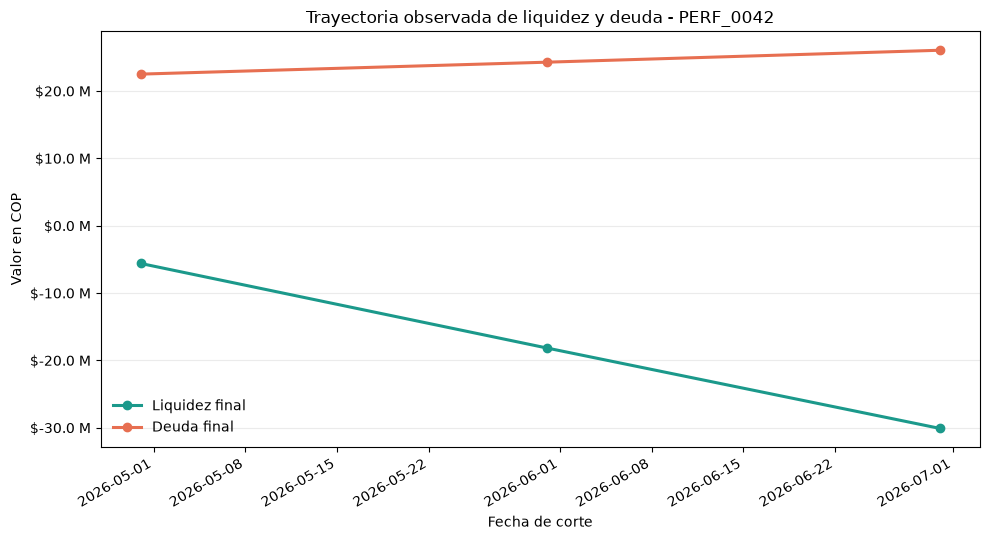

In [19]:
#Graficar trayectoria individual
perfil_grafica = PERFIL_GRAFICA if PERFIL_GRAFICA in trayectorias['perfil_id'].values else trayectorias['perfil_id'].iloc[0]
trayectoria_grafica = trayectorias.loc[
    trayectorias['perfil_id'].eq(perfil_grafica)
].sort_values('fecha_corte')

figura, eje = plt.subplots(figsize=(10, 5.5))
eje.plot(
    trayectoria_grafica['fecha_corte'],
    trayectoria_grafica['liquidez_final'],
    marker='o',
    linewidth=2.2,
    color='#1B998B',
    label='Liquidez final',
)
eje.plot(
    trayectoria_grafica['fecha_corte'],
    trayectoria_grafica['deuda_final'],
    marker='o',
    linewidth=2.2,
    color='#E76F51',
    label='Deuda final',
)

eje.set_title(f'Trayectoria observada de liquidez y deuda - {perfil_grafica}')
eje.set_xlabel('Fecha de corte')
eje.set_ylabel('Valor en COP')
eje.yaxis.set_major_formatter(FuncFormatter(lambda valor, posicion: f'${valor / 1_000_000:.1f} M'))
eje.legend(frameon=False)
eje.grid(axis='y', alpha=0.25)
figura.autofmt_xdate()
figura.tight_layout()
figura.savefig(ruta_graficas / '04_trayectoria_liquidez_deuda.png', dpi=180, bbox_inches='tight')
plt.show()

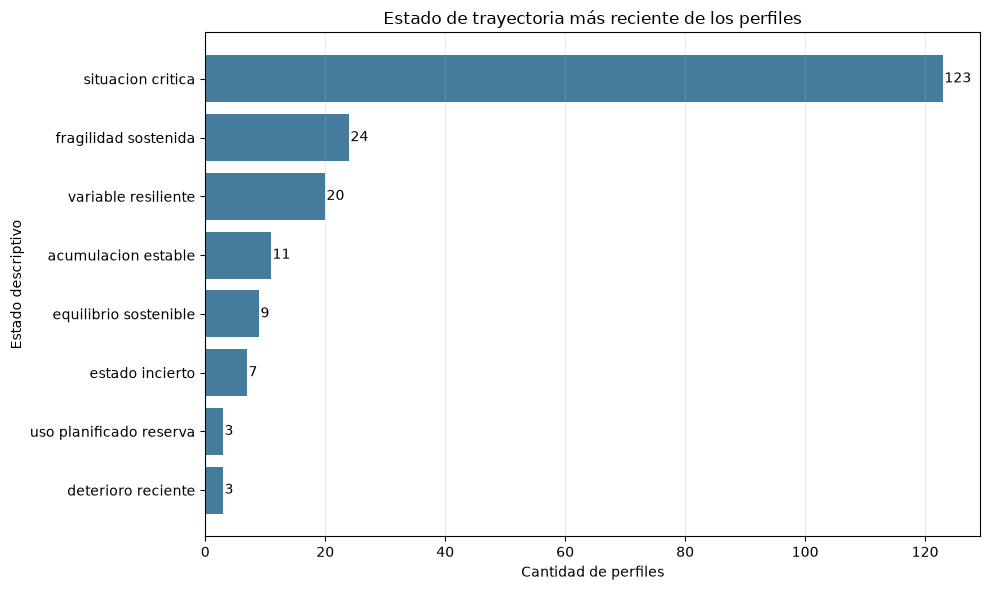

In [20]:
#Graficar estados actuales
distribucion_estados = estado_actual_perfiles['estado_modelo'].value_counts().sort_values()

figura, eje = plt.subplots(figsize=(10, 6))
eje.barh(
    [estado.replace('_', ' ') for estado in distribucion_estados.index],
    distribucion_estados.values,
    color='#457B9D',
)
eje.set_title('Estado de trayectoria más reciente de los perfiles')
eje.set_xlabel('Cantidad de perfiles')
eje.set_ylabel('Estado descriptivo')
eje.grid(axis='x', alpha=0.25)

for posicion, valor in enumerate(distribucion_estados.values):
    eje.text(valor + 0.2, posicion, str(int(valor)), va='center')

figura.tight_layout()
figura.savefig(ruta_graficas / '04_distribucion_estados_actuales.png', dpi=180, bbox_inches='tight')
plt.show()

## 11. Serialización y exportación

In [21]:
#Guardar artefactos
ruta_modelo.parent.mkdir(parents=True, exist_ok=True)
ruta_resultados.mkdir(parents=True, exist_ok=True)

artefacto = {
    'version_modelo': VERSION_MODELO,
    'modelo': modelo_final,
    'modelo_seleccionado': nombre_modelo_final,
    'variables_modelo': variables_modelo,
    'variables_numericas': variables_numericas,
    'variables_contexto': variables_contexto,
    'variables_contexto_modelo': variables_contexto_modelo,
    'indicadores_crudos': indicadores_crudos,
    'umbral_confianza': UMBRAL_CONFIANZA,
    'umbral_confianza_alta': UMBRAL_CONFIANZA_ALTA,
    'min_dias_trayectoria': MIN_DIAS_TRAYECTORIA,
    'min_transacciones_trayectoria': MIN_TRANSACCIONES_TRAYECTORIA,
    'min_pct_clasificable': MIN_PCT_CLASIFICABLE,
    'clases': list(modelo_final.classes_),
    'mapeo_estados_reto': MAPEO_ESTADOS,
    'contextos_ingreso_permitidos': contextos_ingreso_permitidos,
    'formula_deuda': 'deuda_inicial + nueva_deuda - pagos_capital',
    'formula_liquidez': 'liquidez_inicial + entradas - gastos_totales',
    'formula_crecimiento_deuda_modelo': '(deuda_final - deuda_inicial) / actividad_A',
    'formula_gastos_regularidad': 'gastos_fijos + gastos_variables = gastos_totales',
    'version_esquema_trayectorias': 'fincoach_mvp_estructurado_v3.0',
    'version_metodologia_trayectorias': 'roadmap_14_mvp_estructurado_v3.0',
    'definicion_recurrencia': 'patrón temporal observado que no redefine por sí solo un gasto como fijo o variable',
    'metricas_validation': metricas_validation.to_dict(orient='records'),
    'metricas_test': metricas_test.to_dict(orient='records'),
    'ficha_indicadores': ficha_indicadores.to_dict(orient='records'),
    'principio_etico': 'el estado describe una ventana y no la identidad de la persona',
    'atributos_no_utilizados': ['ocupacion', 'ingreso_mensual', 'hobbies', 'habito_ahorro', 'gastos_fijos', 'gastos_variables', 'recurrencias_observadas'],
}

joblib.dump(artefacto, ruta_modelo)

ruta_ventanas = ruta_resultados / '04_estados_por_ventana.csv'
ruta_estados_actuales = ruta_resultados / '04_estados_trayectoria.csv'
ruta_metricas = ruta_resultados / '04_metricas_modelo.csv'

resultados_modelo.to_csv(ruta_ventanas, index=False)
estado_actual_perfiles.to_csv(ruta_estados_actuales, index=False)
pd.concat([
    metricas_validation.assign(particion='validation'),
    metricas_test.assign(particion='test'),
], ignore_index=True).to_csv(ruta_metricas, index=False)

archivos_generados = pd.DataFrame([
    {'artefacto': 'modelo', 'ruta': str(ruta_modelo), 'filas': np.nan},
    {'artefacto': 'estados por ventana', 'ruta': str(ruta_ventanas), 'filas': len(resultados_modelo)},
    {'artefacto': 'estados actuales', 'ruta': str(ruta_estados_actuales), 'filas': len(estado_actual_perfiles)},
    {'artefacto': 'métricas', 'ruta': str(ruta_metricas), 'filas': len(metricas_validation) + len(metricas_test)},
])

display(archivos_generados)

,artefacto,ruta,filas
0,modelo,../Modelos/04_estados_trayectoria.joblib,NaN
1,estados por ventana,../Resultados/04_estados_por_ventana.csv,600.0
2,estados actuales,../Resultados/04_estados_trayectoria.csv,200.0
3,métricas,../Resultados/04_metricas_modelo.csv,3.0


## 12. Pruebas manuales

In [22]:
#Probar ingreso variable resiliente
test_variable_resiliente = {
    'dias_observados': 91,
    'transacciones_observadas': 85,
    'porcentaje_transacciones_clasificables': 97.6471,
    'deuda_inicial': 7501768,
    'deuda_final': 7167768,
    'actividad_A': 24039000,
    'balance_operativo_B': 1557000,
    'presion_deficit_Q': 0,
    'caida_maxima_M': 5001000,
    'tiempo_sin_recuperar_U_dias': 62,
    'recuperacion_R': 0.9161,
    'curvatura_K': 35208.2508,
    'variabilidad_ingresos_V': 0.7074,
    'cobertura_esencial_L_meses': 5.5371,
    'dependencia_externa_X': 0.0171,
    'crecimiento_deuda_J': -0.0445,
    'estado_ingreso_actual': 'estacional',
    'objetivo_declarado': True,
}

resultado_variable = clasificar_trayectoria(test_variable_resiliente)
display(pd.DataFrame([{
    'caso': 'ingreso_variable_con_recuperacion',
    'estado': resultado_variable['estado_trayectoria'],
    'estado_reto': resultado_variable['estado_reto'],
    'confianza_pct': resultado_variable['confianza_pct'],
    'incertidumbre': resultado_variable['nivel_incertidumbre'],
}]))

display(pd.DataFrame([resultado_variable['porcentajes_estado']]))
assert resultado_variable['estado_trayectoria'] == 'variable_resiliente'
assert resultado_variable['estado_reto'] == 'saludable'

,caso,estado,estado_reto,confianza_pct,incertidumbre
0,ingreso_variable_con_recuperacion,variable_resiliente,saludable,68.92,media


,variable_resiliente,acumulacion_estable,equilibrio_sostenible,uso_planificado_reserva,deterioro_reciente,fragilidad_sostenida,situacion_critica
0,68.92,18.88,6.12,4.03,1.25,0.8,0.0


In [23]:
#Probar uso planificado de reserva
test_reserva_planificada = {
    'dias_observados': 30,
    'transacciones_observadas': 30,
    'porcentaje_transacciones_clasificables': 96.6667,
    'deuda_inicial': 1326817,
    'deuda_final': 1842817,
    'actividad_A': 5900000,
    'balance_operativo_B': -3420000,
    'presion_deficit_Q': 3420000,
    'caida_maxima_M': 3370000,
    'tiempo_sin_recuperar_U_dias': 29,
    'recuperacion_R': 0.713,
    'curvatura_K': 0.0,
    'variabilidad_ingresos_V': 0.0,
    'cobertura_esencial_L_meses': 2.5852,
    'dependencia_externa_X': 0.9723,
    'crecimiento_deuda_J': 0.3889,
    'estado_ingreso_actual': 'apoyo',
    'objetivo_declarado': True,
}

resultado_reserva = clasificar_trayectoria(test_reserva_planificada)
display(pd.DataFrame([{
    'caso': 'reserva_con_meta_confirmada',
    'estado': resultado_reserva['estado_trayectoria'],
    'estado_reto': resultado_reserva['estado_reto'],
    'confianza_pct': resultado_reserva['confianza_pct'],
    'incertidumbre': resultado_reserva['nivel_incertidumbre'],
}]))

display(pd.DataFrame([resultado_reserva['porcentajes_estado']]))
assert resultado_reserva['estado_trayectoria'] == 'uso_planificado_reserva'
assert resultado_reserva['estado_reto'] == 'en_observacion'

test_reserva_sin_meta = test_reserva_planificada.copy()
test_reserva_sin_meta['objetivo_declarado'] = False
resultado_reserva_sin_meta = clasificar_trayectoria(test_reserva_sin_meta)
display(pd.DataFrame([{
    'caso': 'reserva_sin_meta_confirmada',
    'estado_calculo': resultado_reserva_sin_meta['estado_calculo'],
    'estado': resultado_reserva_sin_meta['estado_trayectoria'],
    'motivos': resultado_reserva_sin_meta['motivos'],
}]))
assert resultado_reserva_sin_meta['estado_calculo'] == 'requiere_confirmacion'

,caso,estado,estado_reto,confianza_pct,incertidumbre
0,reserva_con_meta_confirmada,uso_planificado_reserva,en_observacion,89.02,baja


,uso_planificado_reserva,fragilidad_sostenida,situacion_critica,deterioro_reciente,acumulacion_estable,equilibrio_sostenible,variable_resiliente
0,89.02,5.15,3.98,1.6,0.26,0.0,0.0


,caso,estado_calculo,estado,motivos
0,reserva_sin_meta_confirmada,requiere_confirmacion,estado_incierto,[uso_de_reserva_sin_meta_confirmada]


In [24]:
#Probar evidencia insuficiente
test_historia_insuficiente = {
    'dias_observados': 1,
    'transacciones_observadas': 1,
    'porcentaje_transacciones_clasificables': 100.0,
    'deuda_inicial': 0,
    'deuda_final': 0,
    'actividad_A': 120000,
    'balance_operativo_B': -120000,
    'presion_deficit_Q': np.nan,
    'caida_maxima_M': np.nan,
    'tiempo_sin_recuperar_U_dias': np.nan,
    'recuperacion_R': np.nan,
    'curvatura_K': np.nan,
    'variabilidad_ingresos_V': np.nan,
    'cobertura_esencial_L_meses': np.nan,
    'dependencia_externa_X': np.nan,
    'crecimiento_deuda_J': np.nan,
    'estado_ingreso_actual': 'variable',
    'objetivo_declarado': True,
}

resultado_insuficiente = clasificar_trayectoria(test_historia_insuficiente)
display(pd.DataFrame([{
    'caso': 'una_sola_transaccion',
    'estado_calculo': resultado_insuficiente['estado_calculo'],
    'estado': resultado_insuficiente['estado_trayectoria'],
    'motivos': resultado_insuficiente['motivos'],
    'porcentajes_estado': resultado_insuficiente['porcentajes_estado'],
}]))

assert resultado_insuficiente['estado_calculo'] == 'evidencia_insuficiente'
assert resultado_insuficiente['estado_reto'] == 'no_disponible'
assert resultado_insuficiente['porcentajes_estado'] == {}

,caso,estado_calculo,estado,motivos,porcentajes_estado
0,una_sola_transaccion,evidencia_insuficiente,no_disponible,[indicadores_faltantes:presion_deficit_Q|caida...,{}
